In [4]:
# Install required packages (run this cell first if you get ModuleNotFoundError)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy'],
    stdout=subprocess.DEVNULL)
print('All packages ready!')

All packages ready!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


# CE322 Pattern Recognition — TikTok Project
## Notebook 4: Unsupervised Learning — Clustering

This notebook applies K-Means and Hierarchical Clustering to discover natural groupings among TikTok videos, and performs a secondary influencer-level cluster analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv('../data/tiktok_features.csv')
with open('../data/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

df_model = df[FEATURE_COLS].dropna()
print(f"Dataset for clustering: {df_model.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

Dataset for clustering: (49459, 30)


## 4.1 K-Means — Elbow Method & Silhouette Score

k=2: inertia=262747.9, silhouette=0.9689
k=3: inertia=239527.7, silhouette=0.1001
k=4: inertia=219936.0, silhouette=0.1167
k=5: inertia=208598.3, silhouette=0.1343
k=6: inertia=196620.6, silhouette=0.1075
k=7: inertia=185369.1, silhouette=0.1389
k=8: inertia=176009.4, silhouette=0.1903
k=9: inertia=165624.2, silhouette=0.2096
k=10: inertia=154256.5, silhouette=0.2170


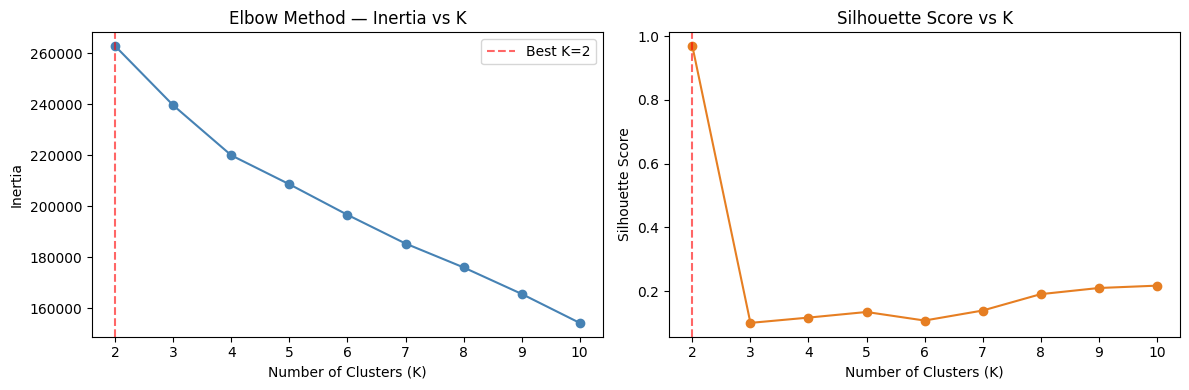


Best K by silhouette: 2


In [6]:
# Sample for speed
from sklearn.utils import resample
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    # Fix: use the full sample (not sub-sample) for silhouette to avoid single-cluster edge case
    try:
        sil = silhouette_score(X_sample, labels)
    except ValueError:
        sil = 0.0
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

best_k = int(np.argmax(silhouettes)) + 2  # k_range starts at 2
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 'o-', color='#e67e22')
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('../data/elbow_silhouette.png', dpi=150)
plt.show()
print(f"\nBest K by silhouette: {best_k}")

## 4.2 K-Means Clustering (Optimal K)

In [7]:
# Use best K found above (or override manually)
OPTIMAL_K = best_k  # auto-selected from silhouette

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_model = df_model.copy()
df_model['kmeans_cluster'] = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_model['kmeans_cluster'], sample_size=5000, random_state=42)
db  = davies_bouldin_score(X_scaled, df_model['kmeans_cluster'])
print(f"K-Means (k={OPTIMAL_K}) — Silhouette: {sil:.4f}  |  Davies-Bouldin: {db:.4f}")
print("\nCluster sizes:")
print(df_model['kmeans_cluster'].value_counts().sort_index())

K-Means (k=2) — Silhouette: 0.0982  |  Davies-Bouldin: 2.9914

Cluster sizes:
kmeans_cluster
0    26720
1    22739
Name: count, dtype: int64


## 4.3 Cluster Profile Analysis

Cluster Profiles (mean values):
                engagement_rate  like_to_play  share_to_play  comment_to_play  duration_seconds  hashtag_count  posting_hour  time_gap_days
kmeans_cluster                                                                                                                             
0                        0.0238        0.0240         0.0011           0.0619           48.6164         4.7242       14.0536       473.6273
1                        0.0380        0.0441         0.0025           0.0004           43.2774         2.6510       14.9970       582.3542


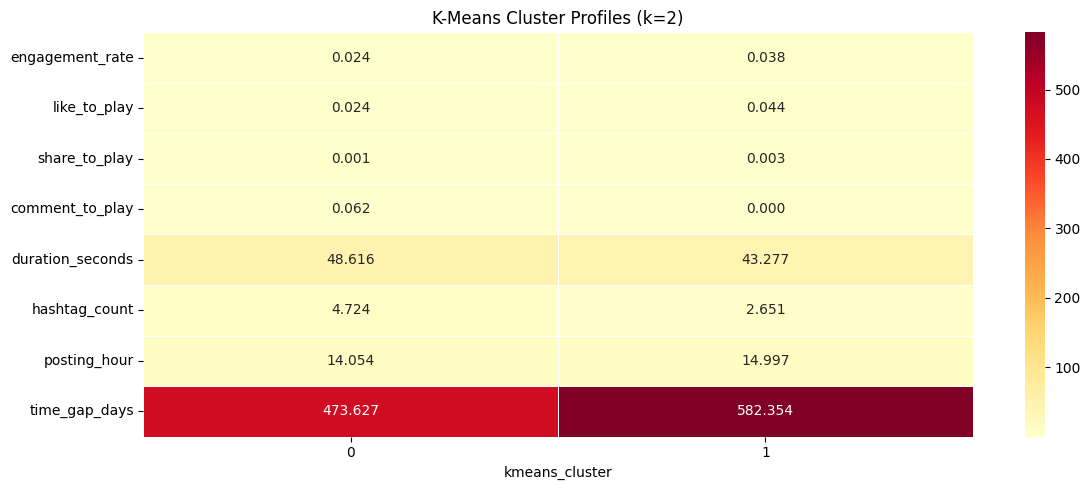

In [8]:
# Merge cluster labels back to full feature df
df_clustered = df[FEATURE_COLS + ['author_username', 'author_category', 'performance_label']].dropna().copy()
df_clustered['kmeans_cluster'] = df_model['kmeans_cluster'].values

profile_cols = ['log_play_count', 'engagement_rate', 'like_to_play', 'share_to_play',
                'comment_to_play', 'duration_seconds', 'hashtag_count',
                'posting_hour', 'time_gap_days']
# use available cols
avail = [c for c in profile_cols if c in df_clustered.columns]

cluster_profile = df_clustered.groupby('kmeans_cluster')[avail].mean().round(4)
print("Cluster Profiles (mean values):")
print(cluster_profile.to_string())
cluster_profile.to_csv('../data/cluster_profiles.csv')

# Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile.T, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title(f'K-Means Cluster Profiles (k={OPTIMAL_K})')
plt.tight_layout()
plt.savefig('../data/cluster_profiles_heatmap.png', dpi=150)
plt.show()

## 4.4 PCA Visualization

PCA explained variance: 0.212


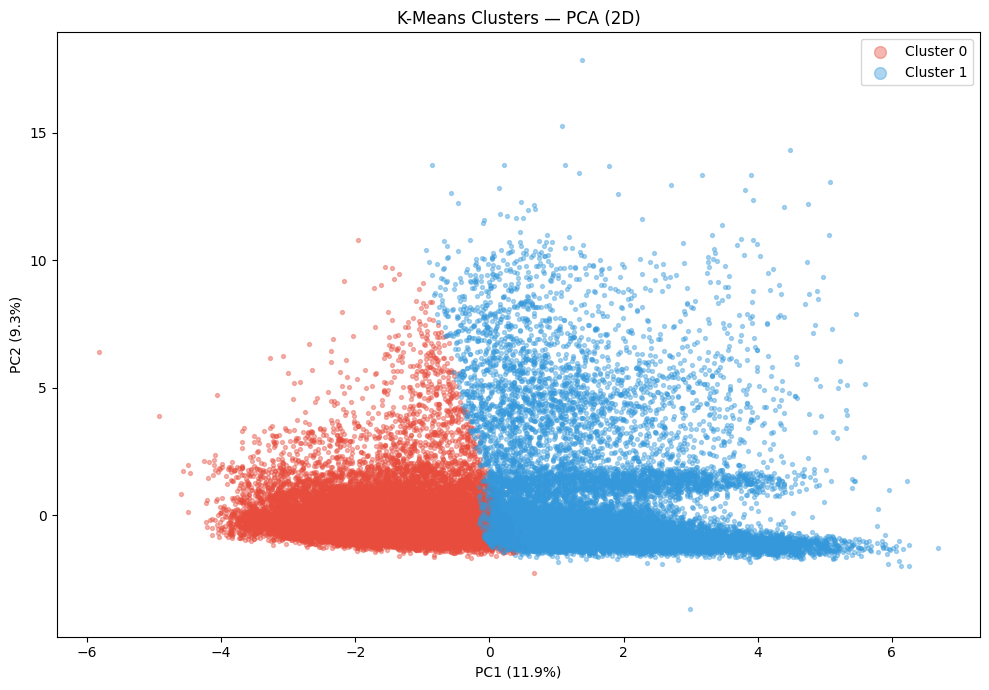

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for c in sorted(df_model['kmeans_cluster'].unique()):
    mask = df_model['kmeans_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=8, alpha=0.4, color=colors[c], label=f'Cluster {c}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Clusters — PCA (2D)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../data/pca_clusters.png', dpi=150)
plt.show()

## 4.5 Hierarchical Clustering (Dendrogram)

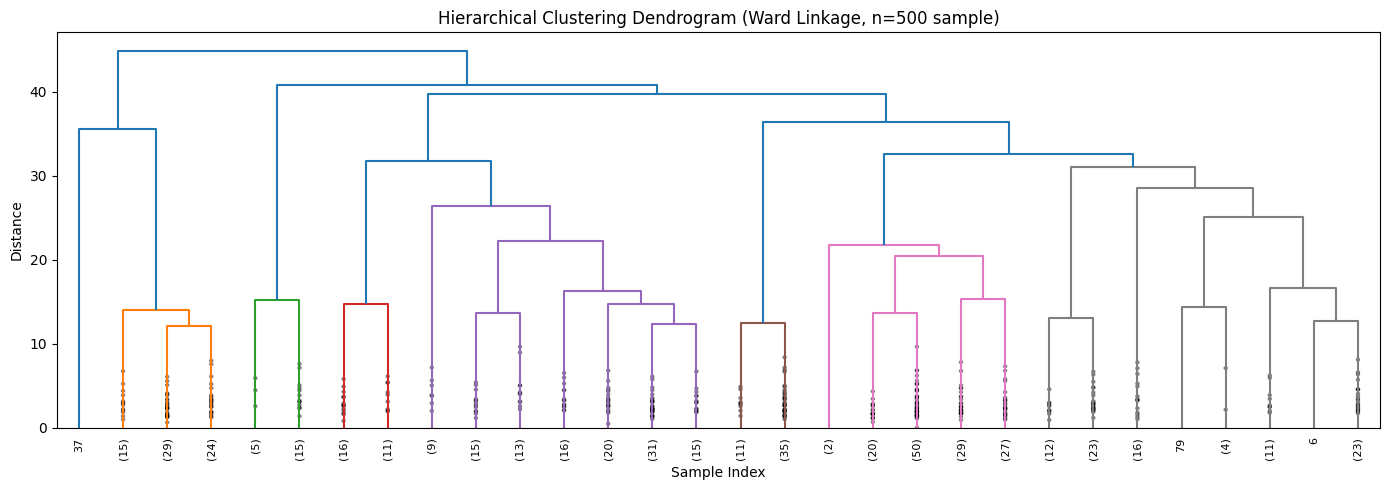

In [10]:
# Use a small sample for dendrogram (too slow on full dataset)
X_hier_sample = resample(X_scaled, n_samples=500, random_state=42)

Z = linkage(X_hier_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8,
           show_contracted=True, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, n=500 sample)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../data/dendrogram.png', dpi=150)
plt.show()

## 4.6 Secondary Analysis — Influencer-Level Clustering

Influencer-level dataset: (214, 11)

Influencer tier distribution:
tier
0     19
1    119
2     76
Name: count, dtype: int64


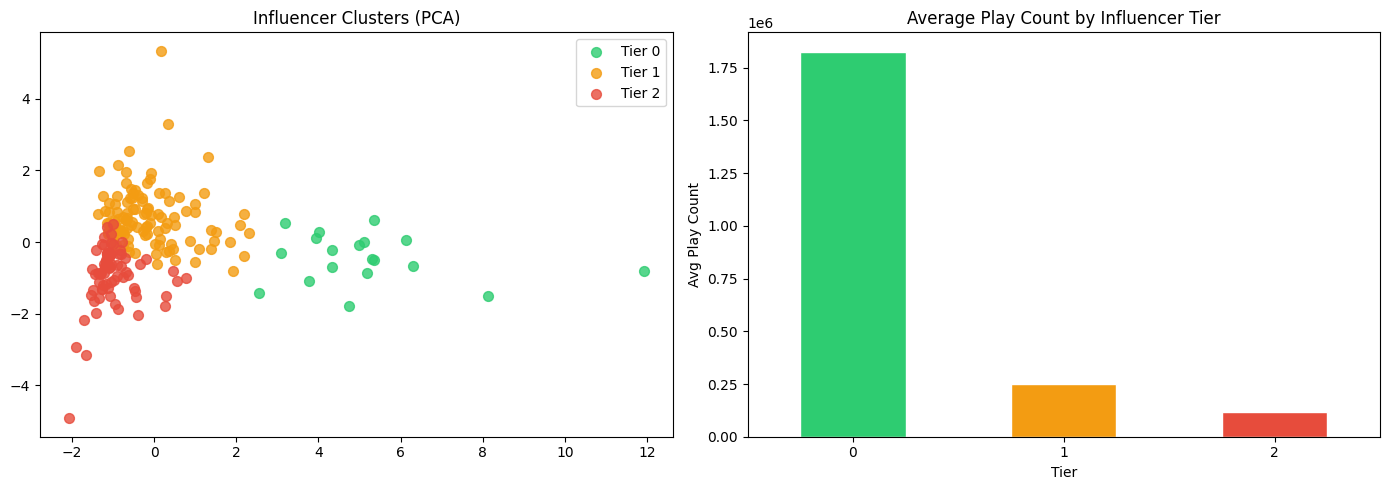

In [11]:
# Aggregate to influencer level
df_full = pd.read_csv('../data/tiktok_features.csv')
influencer_df = df_full.groupby('author_username').agg(
    avg_play_count=('play_count', 'mean'),
    avg_engagement=('engagement_rate', 'mean'),
    avg_likes=('digg_count', 'mean'),
    avg_shares=('share_count', 'mean'),
    avg_comments=('comment_count', 'mean'),
    avg_hashtags=('hashtag_count', 'mean'),
    avg_duration=('duration_seconds', 'mean'),
    avg_posting_hour=('posting_hour', 'mean'),
    video_count=('video_id', 'count'),
    category=('author_category', 'first')
).reset_index()

print(f"Influencer-level dataset: {influencer_df.shape}")

# Cluster influencers
feat_cols_inf = ['avg_play_count', 'avg_engagement', 'avg_likes', 'avg_shares',
                 'avg_comments', 'avg_hashtags', 'avg_duration', 'avg_posting_hour', 'video_count']
X_inf = StandardScaler().fit_transform(influencer_df[feat_cols_inf])

km_inf = KMeans(n_clusters=3, random_state=42, n_init=10)
influencer_df['tier'] = km_inf.fit_predict(X_inf)
tier_labels = {0: 'Tier-A (High)', 1: 'Tier-B (Mid)', 2: 'Tier-C (Low)'}

# Sort tiers by avg play_count
tier_means = influencer_df.groupby('tier')['avg_play_count'].mean().sort_values(ascending=False)
tier_map = {old: new for new, old in enumerate(tier_means.index)}
influencer_df['tier'] = influencer_df['tier'].map(tier_map)

print("\nInfluencer tier distribution:")
print(influencer_df['tier'].value_counts().sort_index())

influencer_df.to_csv('../data/influencer_clusters.csv', index=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_inf = ['#2ecc71', '#f39c12', '#e74c3c']

pca2 = PCA(n_components=2, random_state=42)
X_inf_pca = pca2.fit_transform(X_inf)
for t in [0, 1, 2]:
    mask = influencer_df['tier'] == t
    axes[0].scatter(X_inf_pca[mask, 0], X_inf_pca[mask, 1],
                    s=50, alpha=0.8, color=colors_inf[t], label=f'Tier {t}')
axes[0].set_title('Influencer Clusters (PCA)')
axes[0].legend()

influencer_df.groupby('tier')['avg_play_count'].mean().plot(
    kind='bar', ax=axes[1], color=colors_inf, edgecolor='white')
axes[1].set_title('Average Play Count by Influencer Tier')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Avg Play Count')
axes[1].tick_params(rotation=0)
plt.tight_layout()
plt.savefig('../data/influencer_clusters.png', dpi=150)
plt.show()